In [12]:
import cv2
from ultralytics import YOLO

print("OpenCV version:", cv2.__version__)
print("Libraries imported successfully")

OpenCV version: 5.0.0
Libraries imported successfully


In [13]:
# # Ques 2 
from ultralytics import YOLO

# Load pre-trained YOLOv8 model
model = YOLO("yolov8n.pt")

print("YOLOv8 model loaded successfully")

YOLOv8 model loaded successfully


In [14]:
# # Ques 3

import cv2
import requests

# COCO sample image
image_url = "https://images.cocodataset.org/val2017/000000039769.jpg"
image_path = "coco_sample.jpg"

# Download image
response = requests.get(image_url, verify=False)
response.raise_for_status()

with open(image_path, "wb") as file:
    file.write(response.content)

# Read image using OpenCV
image = cv2.imread(image_path)

print("Image downloaded successfully")
print("Image shape:", image.shape)

d:\shivam\computer_vision\.venv\Lib\site-packages\urllib3\connectionpool.py:1129: InsecureRequestWarning: Unverified HTTPS request is being made to host 'images.cocodataset.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Image downloaded successfully
Image shape: (480, 640, 3)


In [15]:
# # Ques 4

# Resize image
resized_image = cv2.resize(image, (640, 640))

# Normalize pixel values from 0-255 to 0-1
normalized_image = resized_image / 255.0

print("Original image shape:", image.shape)
print("Resized image shape:", resized_image.shape)
print("Normalized pixel range:", normalized_image.min(), "to", normalized_image.max())

Original image shape: (480, 640, 3)
Resized image shape: (640, 640, 3)
Normalized pixel range: 0.0 to 1.0


In [16]:
# # Ques 5
# Apply YOLOv8 object detection

results = model("coco_sample.jpg")

print("Object detection completed successfully")




image 1/1 d:\shivam\computer_vision\Experiment_9\coco_sample.jpg: 480x640 2 cats, 1 couch, 2 remotes, 113.4ms
Speed: 4.3ms preprocess, 113.4ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)
Object detection completed successfully


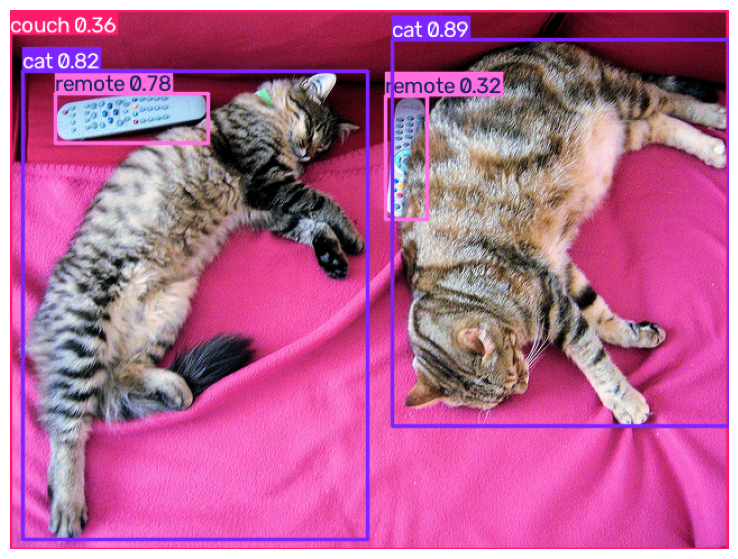

In [17]:
import matplotlib.pyplot as plt

# Get the detected image
detected_image = results[0].plot()

# Convert BGR to RGB for displaying with Matplotlib
detected_image = cv2.cvtColor(detected_image, cv2.COLOR_BGR2RGB)

# Display the result
plt.figure(figsize=(10, 7))
plt.imshow(detected_image)
plt.axis("off")
plt.show()

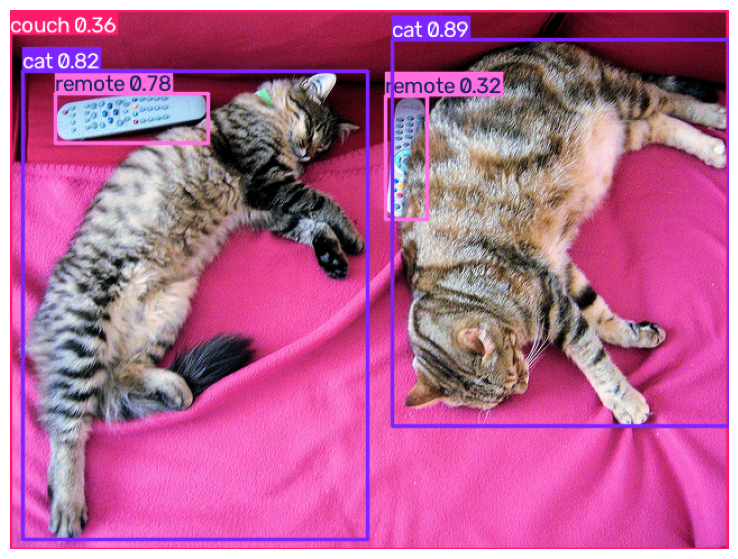

Object: cat | Confidence: 0.89
Object: cat | Confidence: 0.82
Object: remote | Confidence: 0.78
Object: couch | Confidence: 0.36
Object: remote | Confidence: 0.32


In [18]:
# # Ques 6

# Get the first result
result = results[0]

# Display detected objects
output_image = result.plot()

# Convert BGR to RGB
output_image = cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB)

# Show image
plt.figure(figsize=(10, 7))
plt.imshow(output_image)
plt.axis("off")
plt.show()

# Print detected objects with confidence scores
for box in result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    class_name = model.names[class_id]

    print(f"Object: {class_name} | Confidence: {confidence:.2f}")

In [19]:
# # Ques 7

# Evaluate detection results

correct_detections = []
false_detections = []
missed_objects = []

confidence_threshold = 0.50

for box in result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    class_name = model.names[class_id]

    if confidence >= confidence_threshold:
        correct_detections.append((class_name, confidence))
    else:
        false_detections.append((class_name, confidence))

print("Correctly detected objects:")
for name, confidence in correct_detections:
    print(f"{name} - Confidence: {confidence:.2f}")

print("\nLow-confidence detections:")
for name, confidence in false_detections:
    print(f"{name} - Confidence: {confidence:.2f}")

print("\nNumber of correctly detected objects:", len(correct_detections))
print("Number of low-confidence detections:", len(false_detections))
print("Missed objects: Cannot be determined without ground-truth annotations.")

Correctly detected objects:
cat - Confidence: 0.89
cat - Confidence: 0.82
remote - Confidence: 0.78

Low-confidence detections:
couch - Confidence: 0.36
remote - Confidence: 0.32

Number of correctly detected objects: 3
Number of low-confidence detections: 2
Missed objects: Cannot be determined without ground-truth annotations.


In [20]:
import time
from ultralytics import YOLO

# Load two YOLOv8 models
model_n = YOLO("yolov8n.pt")
model_s = YOLO("yolov8s.pt")

# Test YOLOv8n
start_time = time.time()
result_n = model_n("coco_sample.jpg", verbose=False)
time_n = time.time() - start_time

# Test YOLOv8s
start_time = time.time()
result_s = model_s("coco_sample.jpg", verbose=False)
time_s = time.time() - start_time

# Count detections
detections_n = len(result_n[0].boxes)
detections_s = len(result_s[0].boxes)

# Calculate average confidence
confidence_n = (
    float(result_n[0].boxes.conf.mean())
    if len(result_n[0].boxes) > 0 else 0
)

confidence_s = (
    float(result_s[0].boxes.conf.mean())
    if len(result_s[0].boxes) > 0 else 0
)

# Display comparison
print("YOLOv8 Model Comparison")
print("-" * 40)

print(f"YOLOv8n:")
print(f"  Detected objects: {detections_n}")
print(f"  Average confidence: {confidence_n:.2f}")
print(f"  Inference time: {time_n:.4f} seconds")

print()

print(f"YOLOv8s:")
print(f"  Detected objects: {detections_s}")
print(f"  Average confidence: {confidence_s:.2f}")
print(f"  Inference time: {time_s:.4f} seconds")

YOLOv8 Model Comparison
----------------------------------------
YOLOv8n:
  Detected objects: 5
  Average confidence: 0.64
  Inference time: 0.2027 seconds

YOLOv8s:
  Detected objects: 5
  Average confidence: 0.71
  Inference time: 0.8053 seconds


<!-- ## Ques 9 -->
### Analysis of YOLOv8 for Real-World Applications

YOLOv8 is suitable for many real-world object detection applications because it can detect and localize multiple objects in an image or video. It provides bounding boxes, class labels, and confidence scores.

* **Autonomous Driving:** YOLOv8 can be used to detect vehicles, pedestrians, traffic signs, and other road objects. Fast inference makes it useful for real-time perception, but safety-critical systems require extensive testing and additional sensors and algorithms.

* **Surveillance:** It can identify people, vehicles, and other objects in video streams. This can help in monitoring and security applications.

* **Retail Analytics:** YOLOv8 can detect products, customers, and shopping-related objects. It can be used for applications such as inventory monitoring and customer movement analysis.

* **Industrial Inspection:** It can detect objects or visible defects in manufactured products when the model has been trained on suitable domain-specific data.

### Conclusion

YOLOv8 is a practical choice for real-time object detection because of its combination of detection capability and inference speed. However, the model should be trained or fine-tuned with application-specific data and properly evaluated before being used in real-world systems, especially in safety-critical environments.


<!-- ## Ques 10  -->

### Observations

In this experiment, a pre-trained YOLOv8 model was used for object detection. The model successfully identified and localized objects in the selected COCO image using bounding boxes, class labels, and confidence scores. Different YOLOv8 models were also compared based on their detection results and inference time.

### Advantages of Deep Learning-Based Object Detection

1. **High detection capability:** Deep learning models can detect multiple objects in a single image or video.
2. **Automatic feature extraction:** The model learns important visual features automatically from training data.
3. **Real-time detection:** Models such as YOLO can provide fast inference, making them useful for video-based applications.
4. **Multiple applications:** Object detection can be used in surveillance, autonomous systems, retail analytics, and industrial inspection.
5. **Transfer learning:** Pre-trained models can be adapted to new datasets with additional training.

### Limitations

1. **Computational requirements:** Deep learning models can require significant CPU/GPU resources.
2. **Large training datasets:** Good performance generally requires a sufficiently large and representative dataset.
3. **False detections:** The model may incorrectly identify objects, especially in difficult conditions.
4. **Missed objects:** Small, partially hidden, or unclear objects may not be detected correctly.
5. **Domain dependency:** Performance can decrease when the real-world images are significantly different from the training data.
6. **Safety considerations:** For critical applications, extensive testing and validation are required before deployment.

### Conclusion

Deep learning-based object detection provides an effective way to automatically identify and localize objects. YOLOv8 offers a useful balance between detection performance and inference speed, but its reliability depends on the dataset, environment, model configuration, and application requirements.
